In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("typing_speed_train.csv")
print(df.head())
print(df.describe())

         date  days_ago    wpm     acc  rawWpm  consistency
0  2023-01-15       999  76.89  100.00   76.89        64.65
1  2023-01-16       998  81.67  100.00   81.67        79.00
2  2023-01-17       997  66.03   95.08   66.03        65.34
3  2023-01-18       996  93.18  100.00   93.18        75.54
4  2023-01-19       995  94.22   97.92   94.22        65.40
         days_ago         wpm         acc      rawWpm  consistency
count  999.000000  999.000000  999.000000  999.000000   999.000000
mean   500.000000   85.748058   96.192032   89.908298    67.370070
std    288.530761   17.857199    4.044028   19.673983    12.349825
min      1.000000   23.440000   76.190000   26.790000     0.760000
25%    250.500000   72.525000   94.000000   74.415000    59.020000
50%    500.000000   83.540000   96.720000   87.050000    66.570000
75%    749.500000   98.870000  100.000000  105.610000    75.940000
max    999.000000  150.680000  100.000000  150.680000    95.860000


In [3]:
df_numeric = df[['wpm', 'acc', 'rawWpm', 'consistency']]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

In [25]:
import numpy as np

def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 30)

print(X.shape, y.shape)

(969, 30, 4) (969, 4)


In [19]:
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

In [20]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         999 non-null    object 
 1   days_ago     999 non-null    int64  
 2   wpm          999 non-null    float64
 3   acc          999 non-null    float64
 4   rawWpm       999 non-null    float64
 5   consistency  999 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB
None
         days_ago         wpm         acc      rawWpm  consistency
count  999.000000  999.000000  999.000000  999.000000   999.000000
mean   500.000000   85.748058   96.192032   89.908298    67.370070
std    288.530761   17.857199    4.044028   19.673983    12.349825
min      1.000000   23.440000   76.190000   26.790000     0.760000
25%    250.500000   72.525000   94.000000   74.415000    59.020000
50%    500.000000   83.540000   96.720000   87.050000    66.570000
75%    749.500000   98.

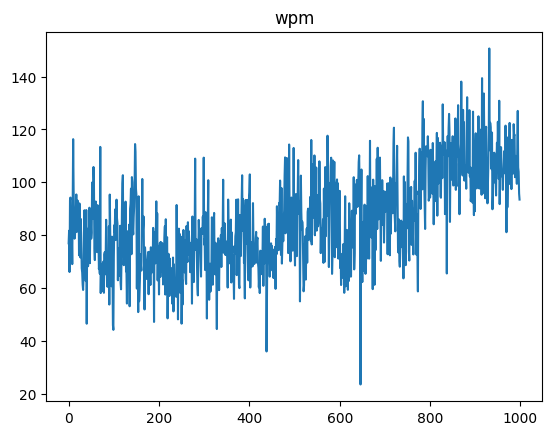

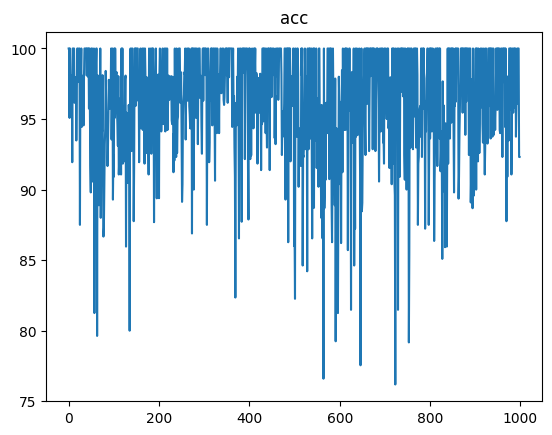

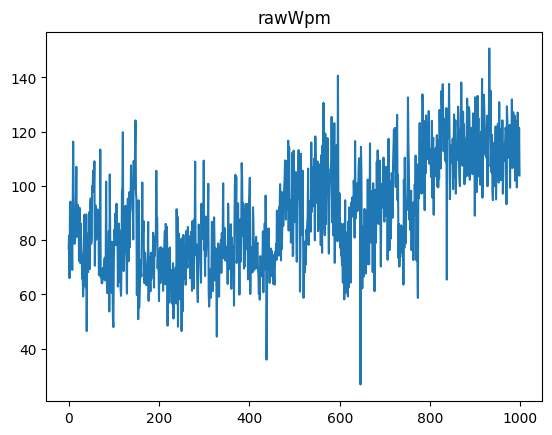

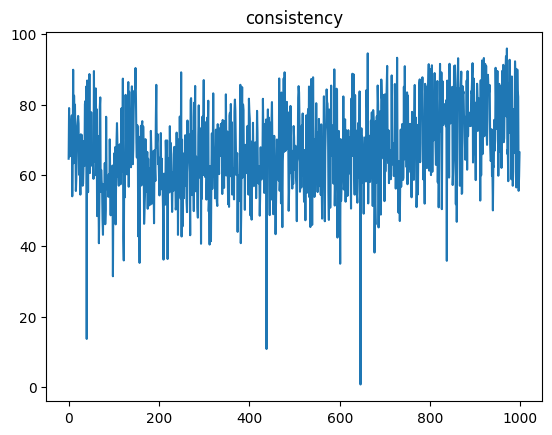

In [9]:
features = ['wpm', 'acc', 'rawWpm', 'consistency']

for col in features:
    plt.figure()
    plt.plot(df[col])
    plt.title(col)
    plt.show()

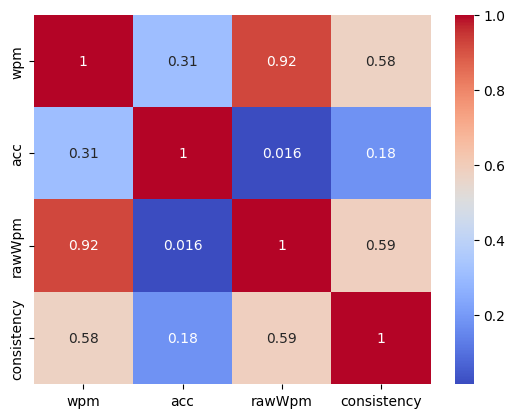

In [10]:
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.show()

In [26]:
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

In [40]:
%pip install tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(30, 4)),
    Dense(32, activation='relu'),
    Dense(4)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, 
          validation_data=(X_val, y_val),
          epochs=10, batch_size=32)

Note: you may need to restart the kernel to use updated packages.
Epoch 1/10


C:\Users\joshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.8063 - val_loss: 1.2010
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.7305 - val_loss: 0.9530
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.7191 - val_loss: 0.6793
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.7106 - val_loss: 0.6784
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.7031 - val_loss: 0.6505
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6988 - val_loss: 0.6609
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6936 - val_loss: 0.6550
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6904 - val_loss: 0.6981
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.6862 - val_loss: 0.7225
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6836 - val_loss: 0.7734


In [44]:
last_real = df[['wpm','acc','rawWpm','consistency']].iloc[-1].values

final_pred = 0.65 * pred[0] + 0.35 * last_real

final_pred[0] = min(final_pred[0], last_real[0] + 5)   
final_pred[2] = min(final_pred[2], last_real[2] + 5)   
final_pred[3] = min(final_pred[3], last_real[3] + 6)   

final_pred[1] = min(max(final_pred[1], 90), 98)

In [46]:
import pandas as pd

pred_df = pd.DataFrame([final_pred], 
    columns=['wpm','acc','rawWpm','consistency'])

pred_df.to_csv("Round3_Predictions_Joshua.csv", index=False)